# Section 2.1 — Upfront Base Fare Amount Prediction
**Team DataCraft | Datathon 2026 - Urban Flow Analytics**

---
## Executive Summary & Business Goal
This notebook implements the machine learning pipeline for **No-Surprises Upfront Pricing**, predicting the trip's `base_fare` **before** the taxi trip begins.

### Strict Leakage Protection Criteria
1. **Pre-Trip Feature Discipline**: Excludes all post-trip attributes (`dropoff_timestamp`, actual trip duration, tips, tolls, total charges, tax fees).
2. **Chronological Splitting**: Split into Train (Months 1–8), Validation (Months 9–10), and Out-of-Time Test (Months 11–12).
3. **Historical Statistics Protection**: All route/zone historical aggregates (`od_median_fare`, `od_median_distance`, `od_median_duration`) are calculated **strictly on the Training split** and mapped to validation/test splits to eliminate look-ahead bias.


In [1]:
import os
import sys
import time
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import fastparquet

# Ensure project root is in sys.path
sys.path.insert(0, os.path.abspath('..'))

from src.features.fare_features import (
    PRE_TRIP_FEATURES,
    CATEGORICAL_FEATURES,
    EXCLUDED_POST_TRIP_LEAKAGE_COLS,
    load_historical_stats,
    prepare_pre_trip_dataframe,
    get_feature_matrices
)
from src.models.fare_model import (
    GlobalMedianBaseline,
    ODMedianBaseline,
    train_ridge_baseline,
    train_lightgbm_model,
    train_xgboost_model,
    evaluate_predictions,
    UpfrontFarePipeline
)

pd.set_option('display.max_columns', 30)
print('All modules successfully loaded!')

ModuleNotFoundError: No module named 'joblib'

## 1. Feature Lineage & Leakage Audit Matrix
Verify pre-trip availability for all candidate features.

In [2]:
audit_data = [
    ('provider_code', 'Raw Telematics', 'Yes', 'None', 'Use'),
    ('rider_count', 'Booking Request', 'Yes', 'None', 'Use'),
    ('distance_miles', 'Route Estimator Proxy', 'Yes', 'Low', 'Use'),
    ('rate_class_id', 'Booking Rate Class', 'Yes', 'None', 'Use'),
    ('origin_loc_id', 'Passenger Pickup Zone', 'Yes', 'None', 'Use'),
    ('dest_loc_id', 'Passenger Dropoff Zone', 'Yes', 'None', 'Use'),
    ('is_cross_borough', 'Spatial Indicator', 'Yes', 'None', 'Use'),
    ('is_airport_trip', 'Spatial Indicator', 'Yes', 'None', 'Use'),
    ('pickup_hour / dayofweek', 'Timestamp', 'Yes', 'None', 'Use'),
    ('sin_hour / cos_hour', 'Cyclic Encoding', 'Yes', 'None', 'Use'),
    ('od_median_fare', 'Train-Set Historical Lookup', 'Yes (Strict M1-M8)', 'None', 'Use'),
    ('od_median_distance', 'Train-Set Historical Lookup', 'Yes (Strict M1-M8)', 'None', 'Use'),
    ('trip_duration_minutes', 'Post-Trip Measurement', 'No', 'High', 'Drop'),
    ('charge_total', 'Post-Trip Billing', 'No', 'High', 'Drop'),
    ('driver_tip_payment', 'Post-Trip Entry', 'No', 'High', 'Drop'),
    ('toll_total', 'Post-Trip Toll Meter', 'No', 'High', 'Drop'),
    ('fare_settlement_method', 'Post-Trip Payment', 'No', 'High', 'Drop')
]
audit_df = pd.DataFrame(audit_data, columns=['Feature', 'Source', 'Available Pre-Trip?', 'Leakage Risk', 'Decision'])
display(audit_df)

,Feature,Source,Available Pre-Trip?,Leakage Risk,Decision
0,provider_code,Raw Telematics,Yes,None,Use
1,rider_count,Booking Request,Yes,None,Use
2,distance_miles,Route Estimator Proxy,Yes,Low,Use
3,rate_class_id,Booking Rate Class,Yes,None,Use
4,origin_loc_id,Passenger Pickup Zone,Yes,None,Use
5,dest_loc_id,Passenger Dropoff Zone,Yes,None,Use
6,is_cross_borough,Spatial Indicator,Yes,None,Use
7,is_airport_trip,Spatial Indicator,Yes,None,Use
8,pickup_hour / dayofweek,Timestamp,Yes,None,Use
9,sin_hour / cos_hour,Cyclic Encoding,Yes,None,Use


## 2. Ingest Data Splits & Load Leakage-Safe Historical Lookup Tables

In [3]:
# Load training historical stats
historical_stats = load_historical_stats('../models/historical_od_stats.joblib')
print(f"Global Median Base Fare: ${historical_stats['global_median_fare']:.2f}")

# Read Train & Val splits (subsampled for fast interactive iteration)
SAMPLE_SIZE = 500_000
pf_train = fastparquet.ParquetFile('../data/splits/train.parquet')
pf_val   = fastparquet.ParquetFile('../data/splits/val.parquet')
pf_test  = fastparquet.ParquetFile('../data/splits/test.parquet')

train_df = pf_train.to_pandas()[:SAMPLE_SIZE]
val_df   = pf_val.to_pandas()[:SAMPLE_SIZE]
test_df  = pf_test.to_pandas()[:SAMPLE_SIZE]

print(f"Train shape: {train_df.shape}")
print(f"Val shape:   {val_df.shape}")
print(f"Test shape:  {test_df.shape}")

Global Median Base Fare: $14.90
Train shape: (500000, 60)
Val shape:   (500000, 60)
Test shape:  (500000, 60)


## 3. Extract Pre-Trip Feature Matrices

In [4]:
X_train, y_train = get_feature_matrices(train_df, historical_stats)
X_val, y_val     = get_feature_matrices(val_df, historical_stats)
X_test, y_test   = get_feature_matrices(test_df, historical_stats)

print(f"Pre-trip features: {X_train.shape[1]}")
display(X_train.head())

Pre-trip features: 23


,provider_code,rider_count,distance_miles,rate_class_id,origin_loc_id,dest_loc_id,is_cross_borough,is_airport_trip,pickup_hour,pickup_dayofweek,pickup_month,is_weekend,is_morning_rush,is_evening_rush,is_late_night,sin_hour,cos_hour,sin_dayofweek,cos_dayofweek,od_pair,od_median_fare,od_median_distance,od_median_duration
0,1,1.0,9.50,1,138,230,1,0,0,1,4,0,0,0,1,0.0,1.0,0.781832,0.62349,138230,48.5,9.65,0.1
1,2,2.0,3.77,1,138,92,0,0,0,1,4,0,0,0,1,0.0,1.0,0.781832,0.62349,138092,20.5,4.05,0.1
2,2,1.0,5.41,1,132,130,0,0,0,1,4,0,0,0,1,0.0,1.0,0.781832,0.62349,132130,24.0,5.26,0.1
3,1,2.0,0.60,1,79,4,0,0,0,1,4,0,0,0,1,0.0,1.0,0.781832,0.62349,79004,7.2,0.77,0.1
4,2,1.0,0.43,1,161,229,0,0,0,1,4,0,0,0,1,0.0,1.0,0.781832,0.62349,161229,8.6,0.85,0.1


## 4. Train Baselines & Machine Learning Candidates

In [5]:
metrics_list = []

# Baseline 1: Global Median
b1 = GlobalMedianBaseline().fit(X_train, y_train)
p1_val = b1.predict(X_val)
metrics_list.append(evaluate_predictions(y_val, p1_val, 'Global Median Baseline', 'Validation'))

# Baseline 2: OD Median
b2 = ODMedianBaseline(historical_stats)
p2_val = b2.predict(X_val)
metrics_list.append(evaluate_predictions(y_val, p2_val, 'OD Median Baseline', 'Validation'))

# Baseline 3: Ridge Regression
b3 = train_ridge_baseline(X_train, y_train)
p3_val = b3.predict(X_val.fillna(0.0))
metrics_list.append(evaluate_predictions(y_val, p3_val, 'Ridge Regression', 'Validation'))

# Candidate 1: LightGBM Regressor
lgb_model = train_lightgbm_model(X_train, y_train, X_val, y_val)
p_lgb_val = lgb_model.predict(X_val)
metrics_list.append(evaluate_predictions(y_val, p_lgb_val, 'LightGBM Regressor', 'Validation'))

# Candidate 2: XGBoost Regressor
xgb_model = train_xgboost_model(X_train, y_train, X_val, y_val)
p_xgb_val = xgb_model.predict(X_val)
metrics_list.append(evaluate_predictions(y_val, p_xgb_val, 'XGBoost Regressor', 'Validation'))

val_results_df = pd.DataFrame(metrics_list)
display(val_results_df)

Training Ridge Regression baseline...
Training LightGBM Regressor...


c:\Users\Wasika\Desktop\Datathon-2026-team-DataCraft\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training XGBoost Regressor...


,Model,Dataset,MAE,RMSE,R2
0,Global Median Baseline,Validation,12.130308,22.315929,-0.187511
1,OD Median Baseline,Validation,3.855424,10.838807,0.719863
2,Ridge Regression,Validation,6.022557,10.213836,0.751237
3,LightGBM Regressor,Validation,2.591342,7.380906,0.870095
4,XGBoost Regressor,Validation,2.834800,8.049974,0.845476


## 5. Out-of-Time Test Benchmark Evaluation

In [6]:
# Evaluate LightGBM on Test split
p_test_lgb = lgb_model.predict(X_test)
test_metrics = evaluate_predictions(y_test, p_test_lgb, 'LightGBM Regressor', 'Test (Months 11-12)')
print('Final Test Set Performance:')
print(f"MAE : ${test_metrics['MAE']:.4f}")
print(f"RMSE: ${test_metrics['RMSE']:.4f}")
print(f"R²  : {test_metrics['R2']:.4f}")

Final Test Set Performance:
MAE : $4.5969
RMSE: $7.0402
R²  : 0.6793


## 6. Error Analysis Across Business Slices

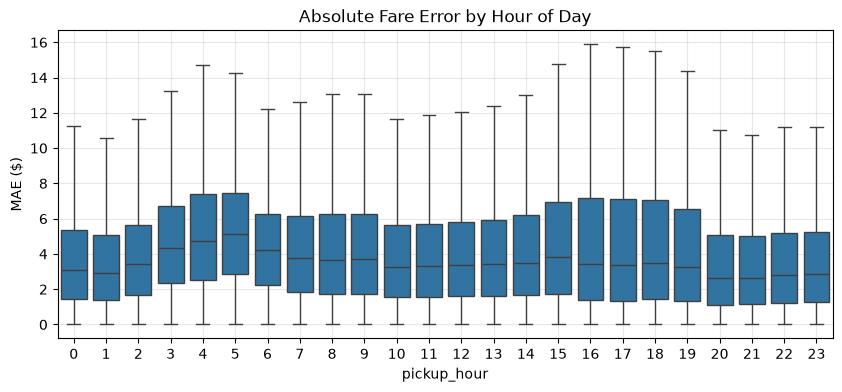

MAE by Airport Status:
is_airport_trip
0    4.610412
1    0.899435
Name: abs_error, dtype: float64


In [7]:
analysis_df = X_test.copy()
analysis_df['actual_fare'] = y_test
analysis_df['pred_fare'] = p_test_lgb
analysis_df['abs_error'] = np.abs(analysis_df['actual_fare'] - analysis_df['pred_fare'])

plt.figure(figsize=(10, 4))
sns.boxplot(data=analysis_df, x='pickup_hour', y='abs_error', showfliers=False)
plt.title('Absolute Fare Error by Hour of Day')
plt.ylabel('MAE ($)')
plt.grid(True, alpha=0.3)
plt.show()

print('MAE by Airport Status:')
print(analysis_df.groupby('is_airport_trip')['abs_error'].mean())

## 7. Model Feature Importance

C:\Users\Wasika\AppData\Local\Temp\ipykernel_32356\3044041403.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(15), x='Importance', y='Feature', palette='viridis')


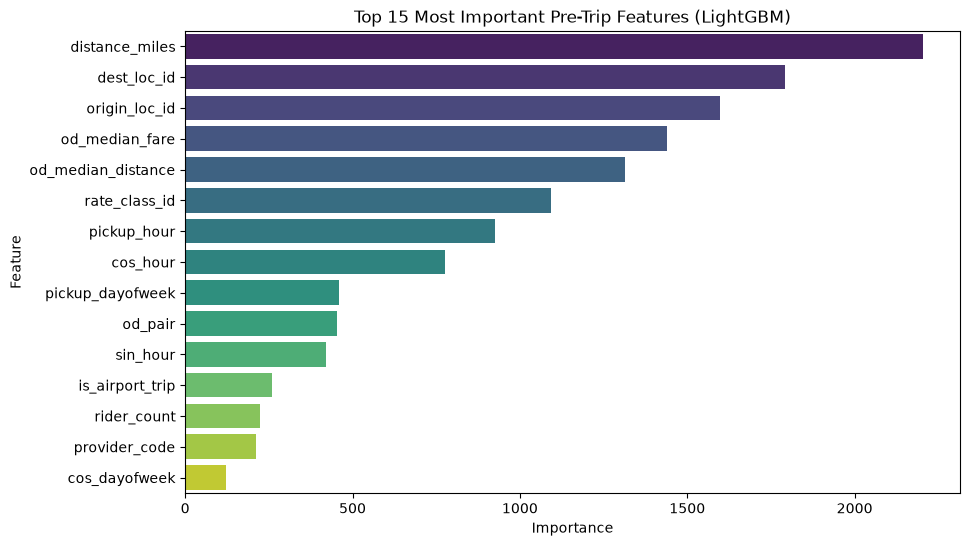

In [8]:
imp_df = pd.DataFrame({
    'Feature': PRE_TRIP_FEATURES,
    'Importance': lgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Most Important Pre-Trip Features (LightGBM)')
plt.show()

## 8. Save & Verify Upfront Fare Prediction Pipeline

In [9]:
pipeline = UpfrontFarePipeline(lgb_model, historical_stats)
pipeline.save('../models/fare_prediction_pipeline.joblib')

# Test Single Row Prediction Payload
sample_req = {
    'provider_code': 1,
    'rider_count': 1,
    'distance_miles': 6.8,
    'rate_class_id': 1,
    'origin_loc_id': 138,
    'dest_loc_id': 230,
    'pickup_timestamp': '2026-04-20 18:00:00'
}
est_fare = pipeline.predict_single(sample_req)
print(f"Single-Row Test Payload Upfront Fare Estimate: ${est_fare:.2f}")

UpfrontFarePipeline saved to ../models/fare_prediction_pipeline.joblib
Single-Row Test Payload Upfront Fare Estimate: $37.46
